## 1) Importar bibliotecas

In [ ]:
# from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input, decode_predictions
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input, EfficientNetV2B2
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
import polars as pl
import numpy as np

## 2) Carregar dados

<p>Rodar sempre para carregar dados</p>

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(y_train.shape)
print(X_train.shape)
print(X_test.shape)
print(y_test.shape)

(50000, 1)
(50000, 32, 32, 3)
(10000, 32, 32, 3)
(10000, 1)


### 2.1) Distribuição de classes no treino 

In [3]:
classes = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

train_target_df = pl.DataFrame(
    data = {
        "target": y_train.reshape(-1, ),
        "description": [classes[index] for index in y_train.reshape(-1, )],
    },
    schema = {
        "target": pl.Int8(),
        "description": pl.String()
    }
)

train_target_df.group_by(
    ["target", "description"]
).agg(
    pl.col("target").len().cast(pl.Int32).alias("total")
).with_columns(
    (pl.col("total")/pl.col("total").sum()).cast(pl.Float32).alias("perc")
).sort(
    by = "target",
)

target,description,total,perc
i8,str,i32,f32
0,"""airplane""",5000,0.1
1,"""automobile""",5000,0.1
2,"""bird""",5000,0.1
3,"""cat""",5000,0.1
4,"""deer""",5000,0.1
5,"""dog""",5000,0.1
6,"""frog""",5000,0.1
7,"""horse""",5000,0.1
8,"""ship""",5000,0.1


### 2.2) Observar fotos de treinamento

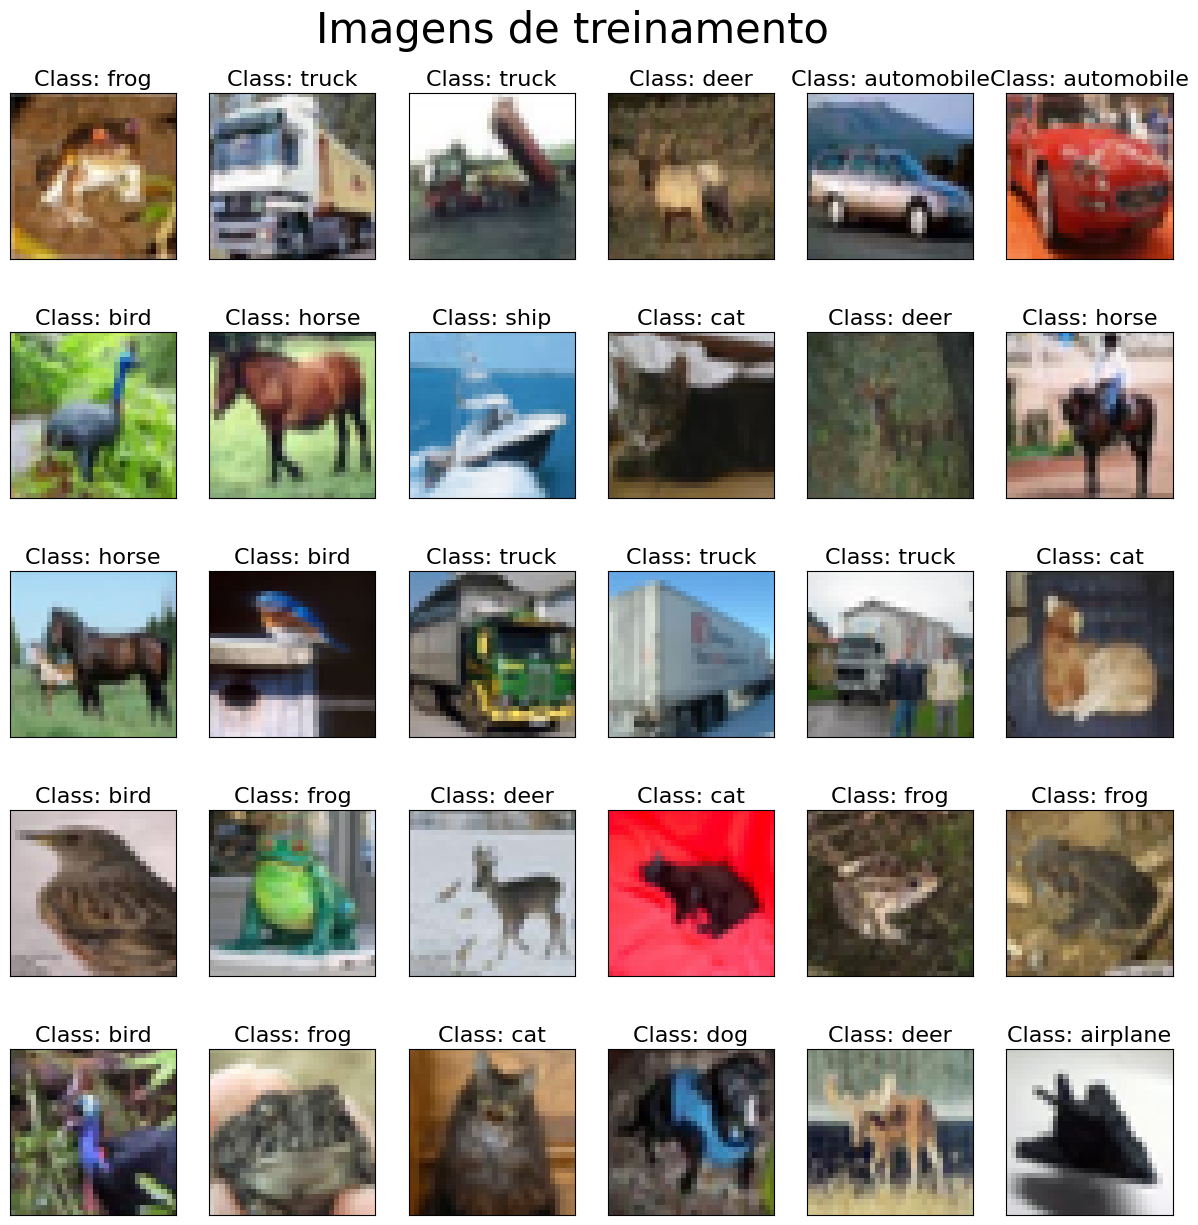

In [4]:
fig, axs = plt.subplots(
    nrows = 5,
    ncols = 6,
    figsize = (15, 15)
)

axs = axs.flatten()

for index, ax in enumerate(axs):

    ax.imshow(X_train[index])
    ax.set_title(f"Class: {classes[y_train[index][0]]}", fontsize = 16)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Imagens de treinamento", fontsize = 30, y = .925)
plt.show()

## 3) Treinando modelos

### 3.1) Definindo funções de teste e treino:

<p>Rodar sempre para treinar dados</p>

#### 3.1.1) <code>early_stopping</code>

In [5]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    min_delta = 1E-4,
    patience = 5,
    verbose = 1,
    monitor = "val_loss",
)

#### 3.1.2) <code>model_compile</code> 

In [6]:
model_compile = {
    "optimizer": tf.keras.optimizers.Adam(1E-4),
    "loss": tf.keras.losses.SparseCategoricalCrossentropy(),
    "metrics": tf.keras.metrics.SparseCategoricalAccuracy()
}

#### 3.1.3) <code>plot_hist</code>

In [7]:
def plot_hist(
    epochs: list[int],
    loss: list[float],
    val_loss: list[float],
    title: str = "Evolução das losses conforme treinamento"
) -> None:

    fig, ax = plt.subplots()

    ax.plot(
        epochs, loss,
        label = "loss",
        marker = ".",
    )
    ax.plot(
        epochs, val_loss,
        label = "val_loss",
        marker = ".",
    )

    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(label = title, fontsize = 16)

    plt.legend()
    plt.show()

#### 3.1.4) <code>model_test</code>

In [8]:
def model_test(model, X_test, y_test, n_images = (5, 6)) -> None:
    
    loss, sparse_categorical_accuracy = model.evaluate(
        x = X_test,
        y = y_test,
        verbose = 0,
    )

    fig, axs = plt.subplots(
        nrows = n_images[0],
        ncols = n_images[1],
        figsize = np.array(n_images)*2.5,
        gridspec_kw = {
            "hspace": 0
        }
    )

    axs = axs.flatten()

    for index, ax in enumerate(axs):

        prediction = model.predict(
            x = tf.expand_dims(
                input = X_test[index],
                axis = 0,
            ),
            verbose = 0,
        )

        color = "green" if y_test[index][0] == prediction.argmax() else "red"

        ax.imshow(
            X_test[index]
        ),
        ax.set_title(
            f"Class: {classes[y_test[index][0]]}", color = color
        )
        ax.set_xlabel(
            f"Predict: {classes[prediction.argmax()]}", color = color
        )
        ax.set_ylabel(
            f"Prob: {prediction.max():.2%}", color = color
        )
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines[["top", "bottom", "left", "right"]].set_color(color)

    plt.suptitle(
        t = f"Amostra de predições teste\nloss: {loss:.3f} | sparse_categorical_accuracy: {sparse_categorical_accuracy:.3f}",
        fontsize = 22,
        y = .925
    )
    plt.show()

#### 3.1.5) <code>plot_model_my_image_test</code>

In [16]:
def plot_model_my_image_test(
    model,
    keep_aspect_ratio = False,
    preprocessing_input = False,
):

    total_correct = 0

    fig, axs = plt.subplots(
        nrows = 5,
        ncols = 6,
        figsize = (12.5, 13.5),
    )

    axs = axs.flatten()

    for index, archive in enumerate(Path("./my_images/cifar10/").iterdir()):

        keras_image = tf.keras.preprocessing.image.load_img(
            path = archive,
            color_mode = 'rgb',
            target_size = (32, 32),
            keep_aspect_ratio = keep_aspect_ratio
        )

        image = tf.keras.preprocessing.image.img_to_array(
            img = keras_image,
            dtype = np.uint8
        )

        prediction = model.predict(
            x = tf.expand_dims(
                input = image if preprocessing_input == False else preprocessing_input(image),
                axis = 0,
            ),
            verbose = 0
        )
        image_name = archive.name.split("_")[0]

        color = "green" if classes[prediction.argmax()] == image_name  else "red"
        total_correct += 1 if color == "green" else 0

        axs[index].imshow(
            image
        )
        axs[index].set_title(
            f"Class: {image_name}", color = color
        )
        axs[index].set_xlabel(
            f"Predict: {classes[prediction.argmax()]}", color = color
        )
        axs[index].set_ylabel(
            f"Prob: {prediction.max():.2%}", color = color
        )
        axs[index].set_xticks([])
        axs[index].set_yticks([])
        axs[index].spines[["left", "right", "top", "bottom"]].set_color(color)

    plt.suptitle(
        t = f"Predições de minhas imagens ({total_correct}/{30})",
        fontsize = 22,
        y = .925
        
    )
    plt.show()


### 3.2) Modelos

#### 3.2.1) Primeiro modelo

##### 3.2.1.1) Construção do modelo

In [ ]:
model1 = tf.keras.Sequential([
    # Configurações de entrada:
    tf.keras.layers.InputLayer(
        shape = (32, 32, 3)
    ),
    tf.keras.layers.Rescaling(
        scale = 1./255
    ),

    # # Configurações de data augmentation
    # tf.keras.layers.RandomZoom(
    #     height_factor = .2,
    #     width_factor = .2,
    # ),
    # tf.keras.layers.RandomRotation(
    #     factor = .2,
    # ),
    # tf.keras.layers.RandomTranslation(
    #     height_factor = .2,
    #     width_factor = .2,
    # ),

    # Filtros:
    tf.keras.layers.Conv2D(
        filters = 64,
        kernel_size = (3, 3),
        strides = (1, 1),
        activation = "relu",
    ),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(
        filters = 128,
        kernel_size = (3, 3),
        strides = (1, 1),
        activation = "relu",
    ),
    tf.keras.layers.MaxPooling2D(),

    # Neurônios de saída:
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(
        units = 10,
        activation = "softmax",
    )
])

model1.compile(
    optimizer = model_compile["optimizer"],
    loss = model_compile["loss"],
    metrics = [model_compile["metrics"]],
)

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        46,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,738 (475.54 KB)

 Trainable params: 121,738 (475.54 KB)

 Non-trainable params: 0 (0.00 B)

##### 3.2.1.2) Fit do modelo

In [ ]:
history1 = model1.fit(
    x = X_train,
    y = y_train,
    batch_size = 32,
    epochs = 100,
    validation_split = 0.2,
    callbacks = [early_stopping]
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - loss: 1.4735 - sparse_categorical_accuracy: 0.4753 - val_loss: 1.1911 - val_sparse_categorical_accuracy: 0.5804
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - loss: 1.0946 - sparse_categorical_accuracy: 0.6202 - val_loss: 1.0628 - val_sparse_categorical_accuracy: 0.6401
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - loss: 0.9583 - sparse_categorical_accuracy: 0.6680 - val_loss: 0.9966 - val_sparse_categorical_accuracy: 0.6623
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - loss: 0.8762 - sparse_categorical_accuracy: 0.6998 - val_loss: 0.9448 - val_sparse_categorical_accuracy: 0.6770
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - loss: 0.8081 - sparse_categorical_accuracy: 0.7193 - val_loss: 0.9191 - val_sparse_categorical_accuracy: 0.6913
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - loss: 0.7469 - sparse_categorical_accuracy: 0.7406 - val_loss: 0.9144 - val_sparse_cat

##### 3.2.1.3) Qualidade do treinamento

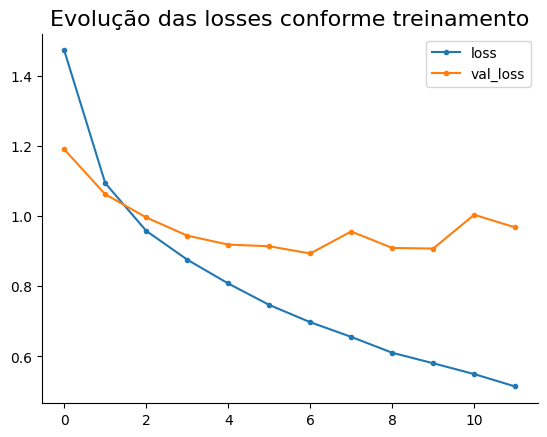

In [ ]:
plot_hist(
    epochs = history1.epoch,
    loss = history1.history["loss"],
    val_loss = history1.history["val_loss"],
)

##### 3.2.1.4) Testar modelo

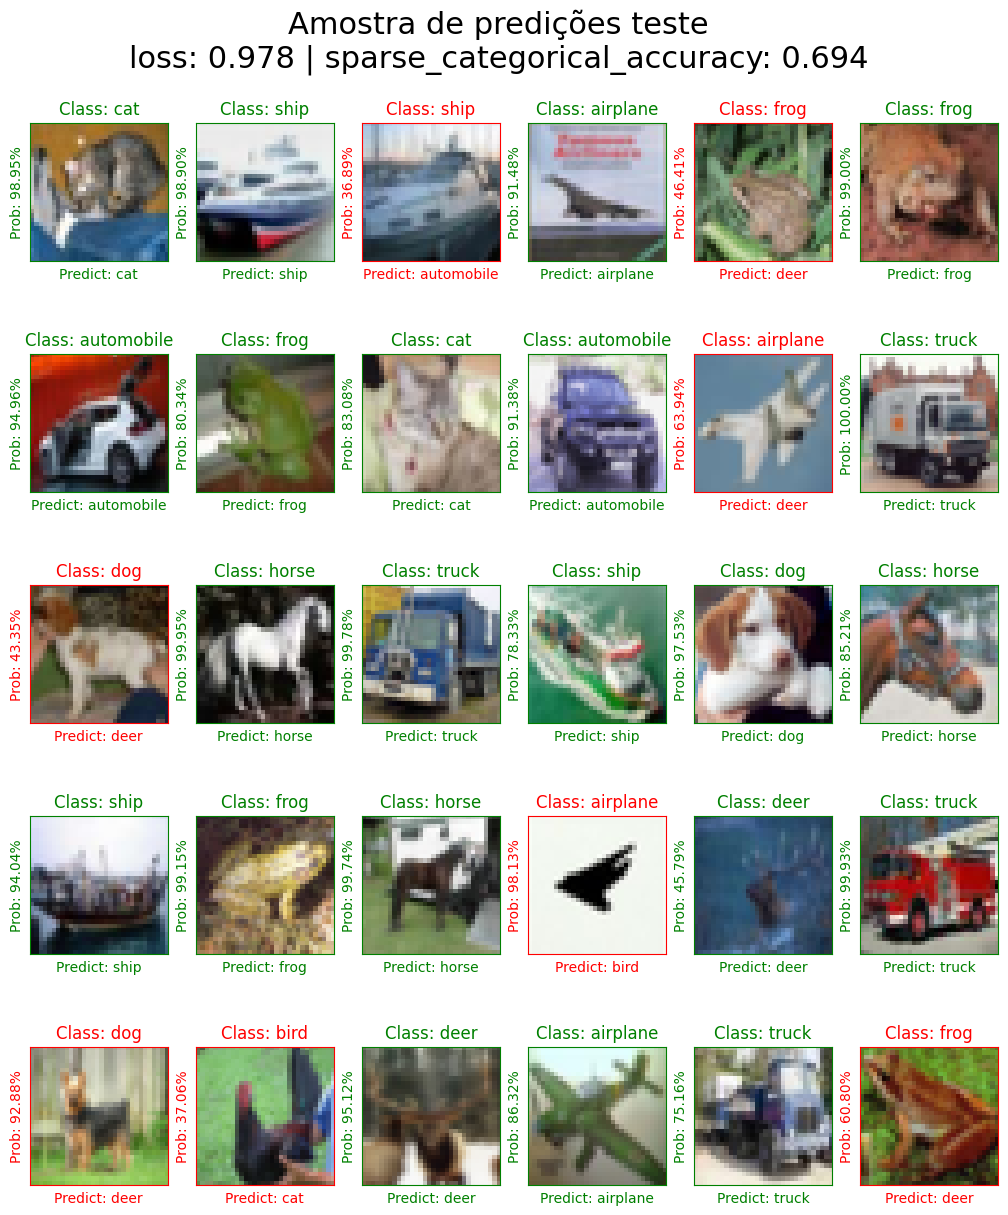

In [ ]:
model_test(
    model = model1,
    X_test = X_test,
    y_test = y_test,
)

##### 3.2.1.5) Testar minhas imagens

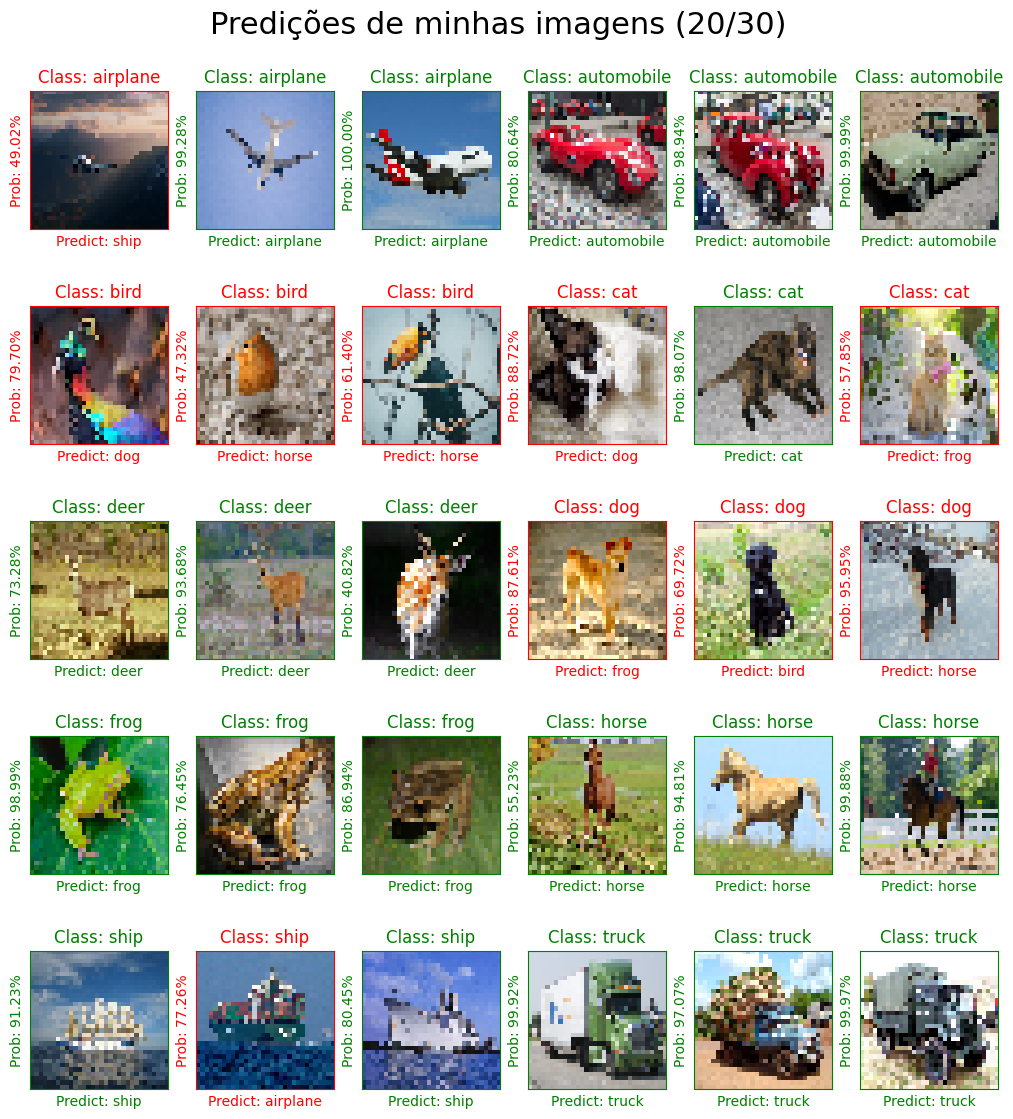

In [ ]:
plot_model_my_image_test(
    model = model1,
    keep_aspect_ratio = False
)

#### 3.2.2) Segundo modelo

##### 3.2.2.1) Construção do modelo

In [11]:
model2 = tf.keras.Sequential([
    # Configurações de entrada:
    tf.keras.layers.InputLayer(
        shape = (32, 32, 3)
    ),
    tf.keras.layers.Rescaling(
        scale = 1./255
    ),

    # Configurações de data augmentation
    tf.keras.layers.RandomZoom(
        height_factor = .2,
        width_factor = .2,
    ),
    tf.keras.layers.RandomRotation(
        factor = .2,
    ),
    tf.keras.layers.RandomTranslation(
        height_factor = .2,
        width_factor = .2,
    ),

    # Filtros:
    tf.keras.layers.Conv2D(
        filters = 64,
        kernel_size = (3, 3),
        strides = (1, 1),
        activation = "relu",
        padding = "same",
    ),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Conv2D(
        filters = 128,
        kernel_size = (3, 3),
        strides = (1, 1),
        activation = "relu",
        padding = "same",
    ),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.2),

    # Neurônios de saída:
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(
        units = 10,
        activation = "softmax",
    )
])

model2.compile(
    optimizer = model_compile["optimizer"],
    loss = model_compile["loss"],
    metrics = [model_compile["metrics"]],
)

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        81,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,578 (615.54 KB)

 Trainable params: 157,578 (615.54 KB)

 Non-trainable params: 0 (0.00 B)

##### 3.2.2.2) Fit do modelo

In [12]:
history2 = model2.fit(
    x = X_train,
    y = y_train,
    batch_size = 32,
    epochs = 100,
    validation_split = 0.2,
    callbacks = [early_stopping]
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 37ms/step - loss: 1.8617 - sparse_categorical_accuracy: 0.3252 - val_loss: 1.7819 - val_sparse_categorical_accuracy: 0.3843
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - loss: 1.7090 - sparse_categorical_accuracy: 0.3851 - val_loss: 1.6571 - val_sparse_categorical_accuracy: 0.4290
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - loss: 1.6428 - sparse_categorical_accuracy: 0.4110 - val_loss: 1.4555 - val_sparse_categorical_accuracy: 0.4869
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - loss: 1.5930 - sparse_categorical_accuracy: 0.4284 - val_loss: 1.3697 - val_sparse_categorical_accuracy: 0.5251
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - loss: 1.5561 - sparse_categorical_accuracy: 0.4448 - val_loss: 1.3996 - val_sparse_categorical_accuracy: 0.5125
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - loss: 1.5404 - sparse_categorical_accuracy: 0.4505 - val_loss: 1.4313 - val_sparse_cat

##### 3.2.2.3) Qualidade do treinamento

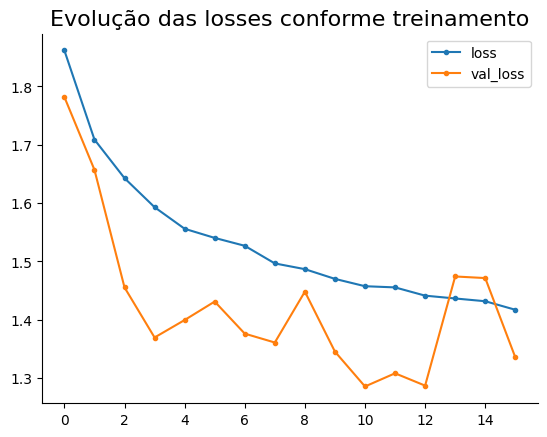

In [13]:
plot_hist(
    epochs = history2.epoch,
    loss = history2.history["loss"],
    val_loss = history2.history["val_loss"],
)

##### 3.2.2.4) Testar modelo

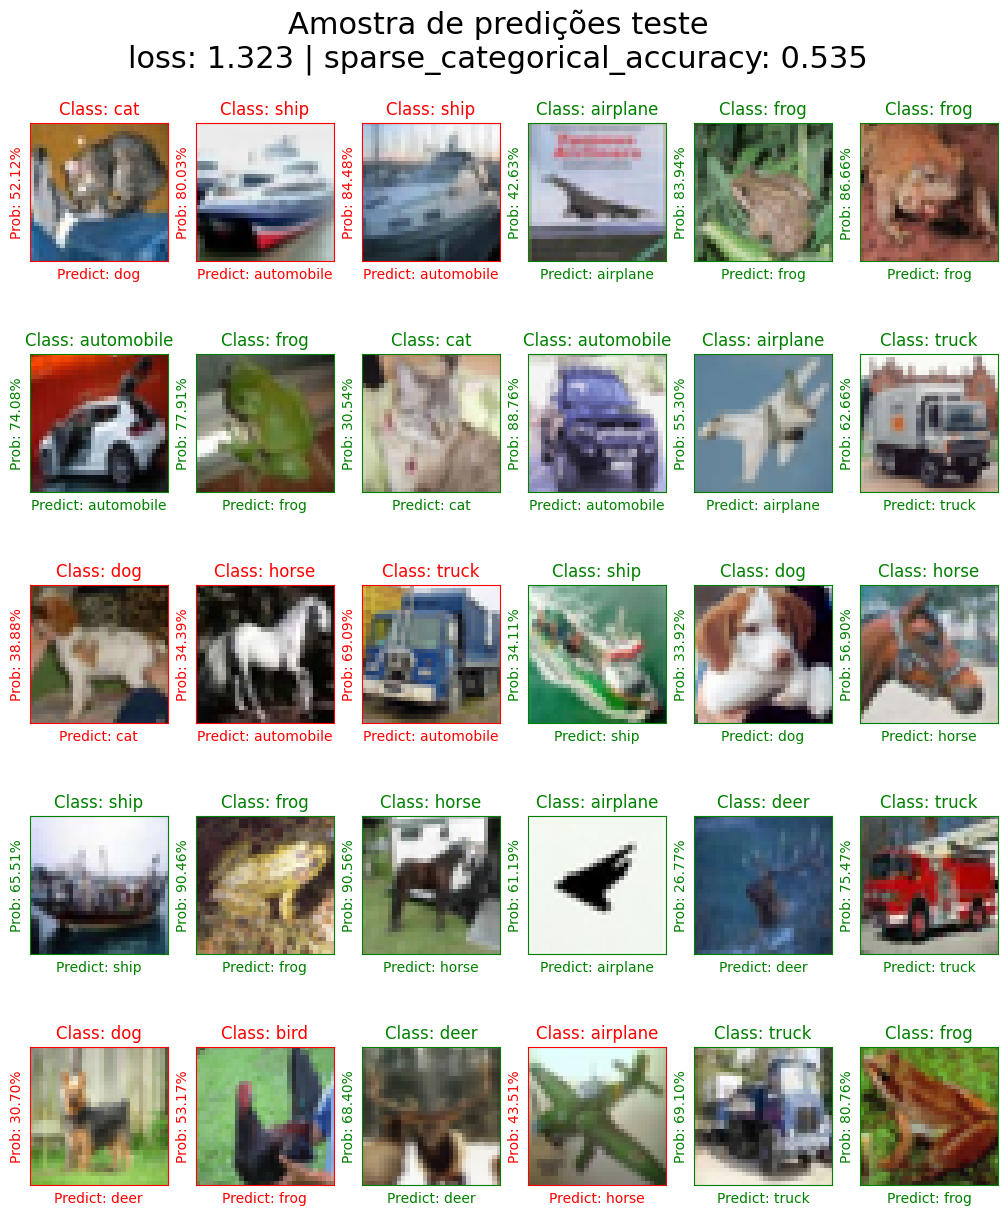

In [14]:
model_test(
    model = model2,
    X_test = X_test,
    y_test = y_test,
)

##### 3.2.2.5) Testar minhas imagens

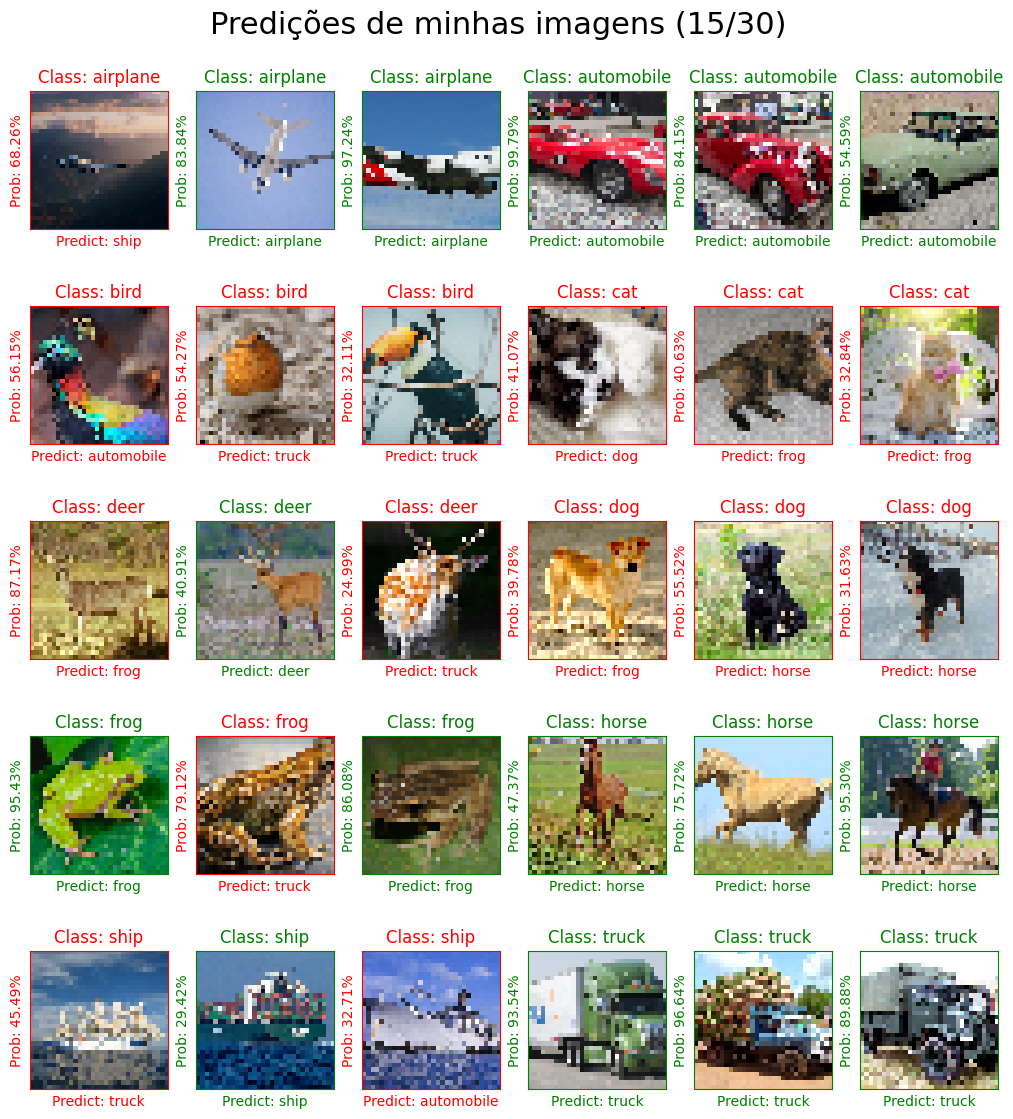

In [16]:
plot_model_my_image_test(
    model = model2,
    keep_aspect_ratio = True
)

#### 3.2.3) Terceiro modelo

##### 3.2.3.1) Construção do terceiro

In [14]:
# 1. Defina a base (tem que ser IDÊNTICA à do treino)
base_model = EfficientNetV2B2(
    weights=None, # Não precisa baixar do ImageNet agora, vamos carregar os seus
    include_top=False,
    input_shape=(260, 260, 3)
)

# 2. Monte o esqueleto do modelo
model3 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(32, 32, 3)),
    tf.keras.layers.Resizing(260, 260, interpolation='bilinear'),
    base_model,
    tf.keras.layers.GlobalMaxPooling2D(),
    tf.keras.layers.Dense(4096, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4096, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=10, activation="softmax")
])

# 3. A MÁGICA: Carregar apenas os pesos de dentro do arquivo .keras
# O parâmetro skip_mismatch=True ajuda se houver pequenas diferenças
model3.load_weights("./models/cifar10/cifar10.keras")

model3.compile(
    optimizer = model_compile["optimizer"],
    loss = model_compile["loss"],
    metrics = [model_compile["metrics"]]
)

print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


##### 3.2.3.2) Testar modelo

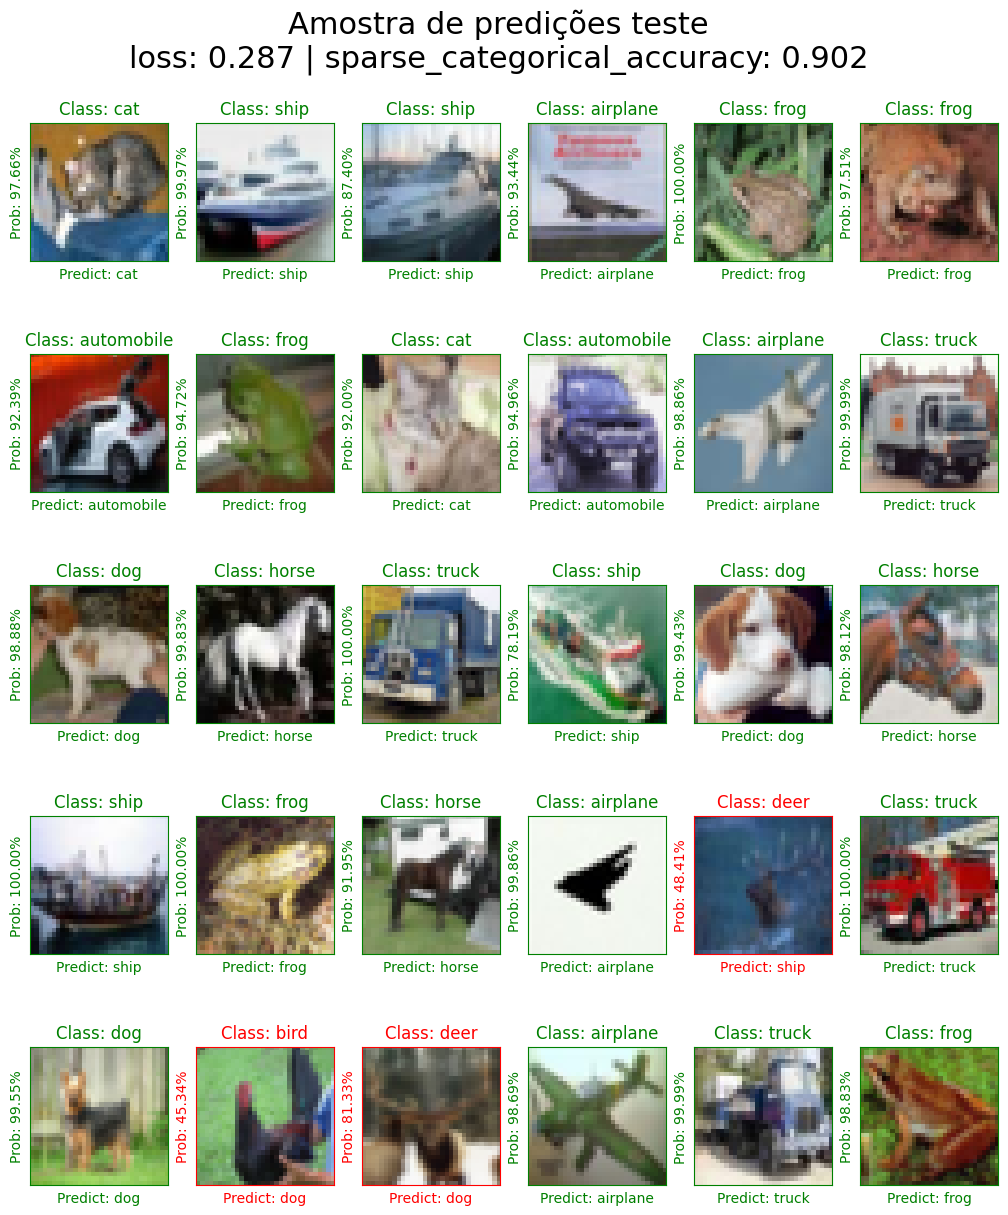

In [15]:
model_test(
    model = model3,
    X_test = preprocess_input(X_test),
    y_test = y_test,
)

##### 3.2.3.3) Testar minhas imagens

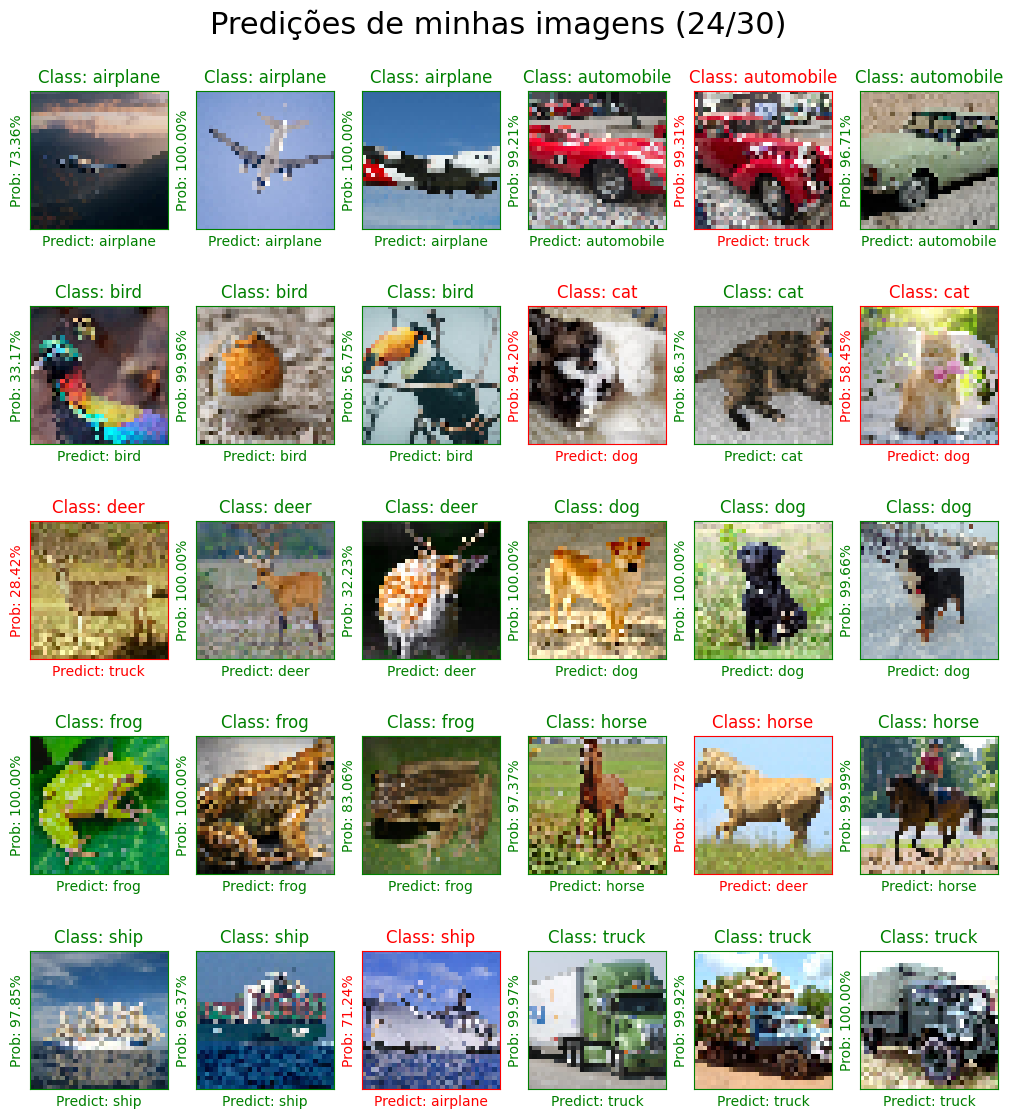

In [17]:
plot_model_my_image_test(
    model = model3,
    keep_aspect_ratio = True,
    preprocessing_input = preprocess_input
)

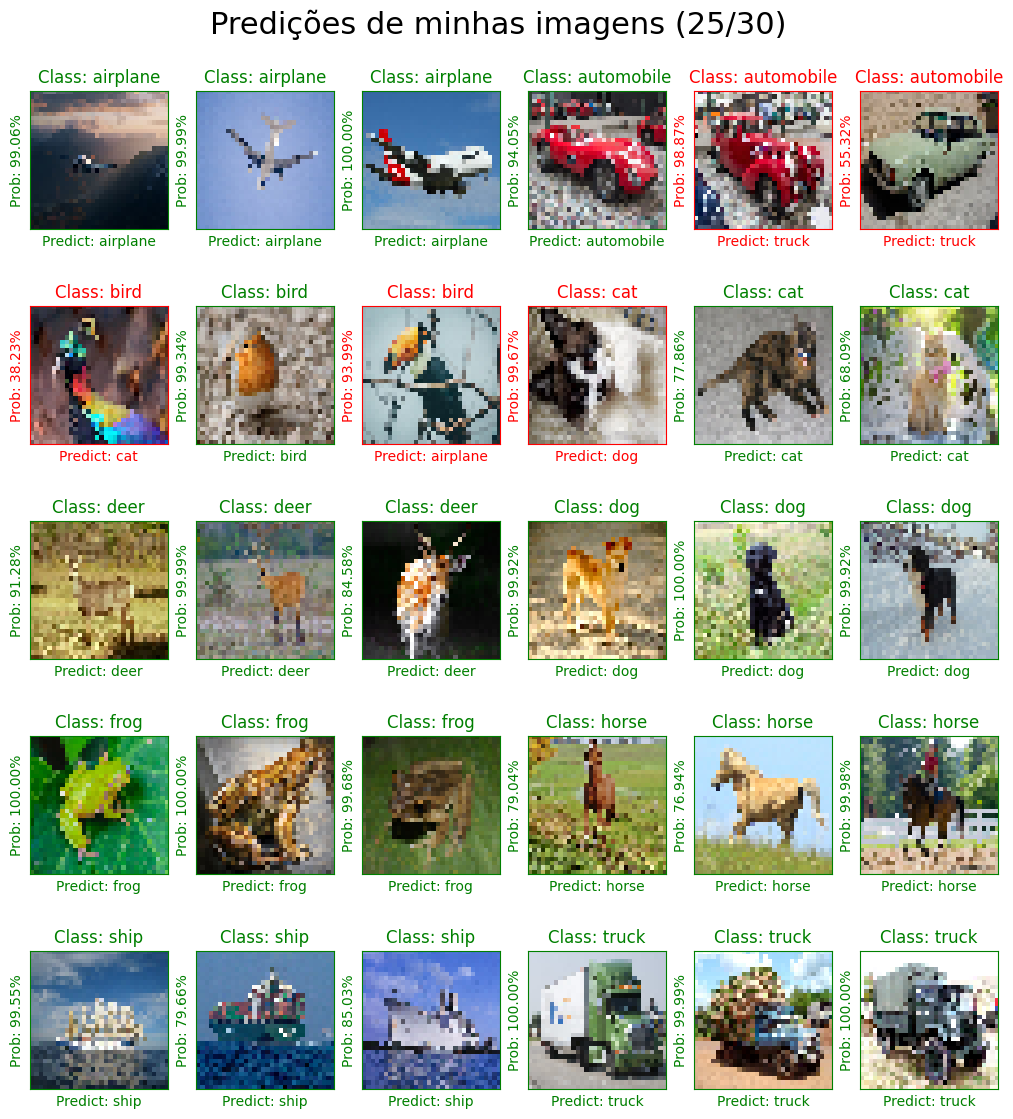

In [18]:
plot_model_my_image_test(
    model = model3,
    keep_aspect_ratio = False,
    preprocessing_input = preprocess_input
)